<a href="https://colab.research.google.com/github/GutoOliva/Titanic-Machine_Learning_from_Disaster/blob/main/Titanic_Machine_Learning_from_Disaster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TITANIC: Machine Learning from Disaster**

---

The Titanic Challenge is a very famous competition promoted by [Kaggle.com.](https://kaggle.com)

Most people are probably familiar with the story behind the sinking of what was supposed to be the most modern ship of its time. Despite the available technology, after colliding with an iceberg on April 15, 1912, **its sinking killed 1,502 people out of a total of 2,224 passengers.**

It was soon discovered that one of the main contributing factors was the lack of enough lifeboats for all passengers and crew members.

Obviously, those who survived the tragedy were very lucky — but could it be that some groups of passengers were “luckier” than others? Did women and children really have higher chances of survival? Did Jack have fewer chances of escaping his tragic fate than Rose just because he was traveling in 3rd class?

With the **real data** made available, you can now perform exploratory analysis, test your hypotheses, and even build a predictive model (how about discovering what your chances of survival would have been if you had traveled in 1st class with your wife and child?!)

> In short, the goal of this challenge is to use the available data to measure the passengers’ chances of survival on the Titanic.

The idea is to introduce the topic of **Data Science** to beginners in the field. Therefore, I tried not to go too deep into complex concepts or analyses, so that all steps can be reproduced and understood easily.

---

## **Steps**
1. Problem Definition  
2. Data Collection  
3. Data Exploration  
4. Data Preparation  
5. Model Building  
6. Evaluation  

---

## **Problem Definition**

The construction of the Titanic took about two years and cost 7.5 million dollars (at that time). It was 269 meters long, 28 meters wide, and 53 meters high, operated by a crew of 892 people, and could carry up to 2,435 passengers (spread across three different classes).

Designed to be the safest and most luxurious ship of its time, it was launched in 1911, quickly earning the reputation of being “unsinkable.”

The full description of the competition, as well as the dataset, is available on the Kaggle page: *Titanic: Machine Learning from Disaster.*

The sinking of the Titanic was caused by both natural factors (such as weather) and human factors (like negligence and overconfidence). Regardless of the causes, the fact is that the tragedy claimed 1,502 lives out of 2,224 passengers.

Although luck certainly played a part in who survived, some groups of people were more likely to escape death than others — for instance, women, children, and first-class passengers. Therefore, it’s clear that some **patterns** can be extracted from the raw data.

---

## **Objective**

You are expected to analyze which variables had the greatest influence on the probability of survival — in other words, **what kind of person had a higher chance of escaping alive.**

After analyzing the data, you should also be able to build a **predictive model** that estimates the survival chances of any passenger when provided as input.

---

### **Performance Metric**

The score is calculated based on the number of correct predictions your model makes. In other words, **only the model’s accuracy** is considered.

---

### **Data Collection**

The datasets provided by Kaggle are divided into two groups:

* **Training Dataset (train.csv)**  
  * Should be used to build the Machine Learning model. In this dataset, the “Survived” column indicates whether the passenger lived or not.  
  * It contains several features such as passenger gender and travel class.  

* **Test Dataset (test.csv)**  
  * Should be used as unseen data — information the model has never been trained on. In this dataset, the “Survived” column is not provided.  

A **sample submission file** (`gender_submission.csv`) is also provided as a reference for how your predictions should be formatted before being submitted to Kaggle.


In [388]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

path_train = '/content/drive/MyDrive/Colab Notebooks/train.csv'
path_test = '/content/drive/MyDrive/Colab Notebooks/test.csv'

# Allow viewing of all columns
pd.options.display.max_columns = None

# Read csv files
train = pd.read_csv(path_train)
test = pd.read_csv(path_test)

train.head()
# test.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**-** How many variables (columns) and how many entries (rows) document has

In [389]:
print("Variables:\t{}\nEntries:\t{}".format(train.shape[1], train.shape[0]))

Variables:	12
Entries:	891


## **Data exploration**

In an initial analysis, each variable will be studied. It's important to check its name, type, percentage of missing values, presence of outliers, and distribution type.

Since this is Supervised Learning, the "Survived" variable is defined as our target variable.

### **Data Dictionary**

*   **PassangerId:** Passenger Identification number
*   **Survived:** Reports whether the passenger survived the disaster (0,1)
*   **Pclass:** Reports tickets class (0,1)
*   **Name:** Passenger name
*   **Sex:** Passagenger Sex
*   **Age:** Passagenger Age
*   **SibSp:** Number of spouses and siblings on board
*   **Parch:** Number of parents and children on board
*   **Ticket:** Ticket Number
*   **Fare:** Ticket price
*   **Cabin:** Passenger cabin number
*   **Embarked:** Port at which passenger embarks
      * C = Cherbourg
      * Q = Quennstown
      * S = Southampton


In [390]:
# Identify each type of variable
display(train.dtypes)

# View the first 5 entries of the train database
display(train.head())

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Check % of NaN values

**Cabin** information has the most missing information, at over **77%**. Next, the **Age** column is missing for almost **20%** of passengers. Finally, the Port of **Embarkation** column has only **2%** of missing information.

In [391]:
(train.isnull().sum() / train.shape[0]).sort_values(ascending=False)

,0
Cabin,0.771044
Age,0.198653
Embarked,0.002245
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


In [392]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


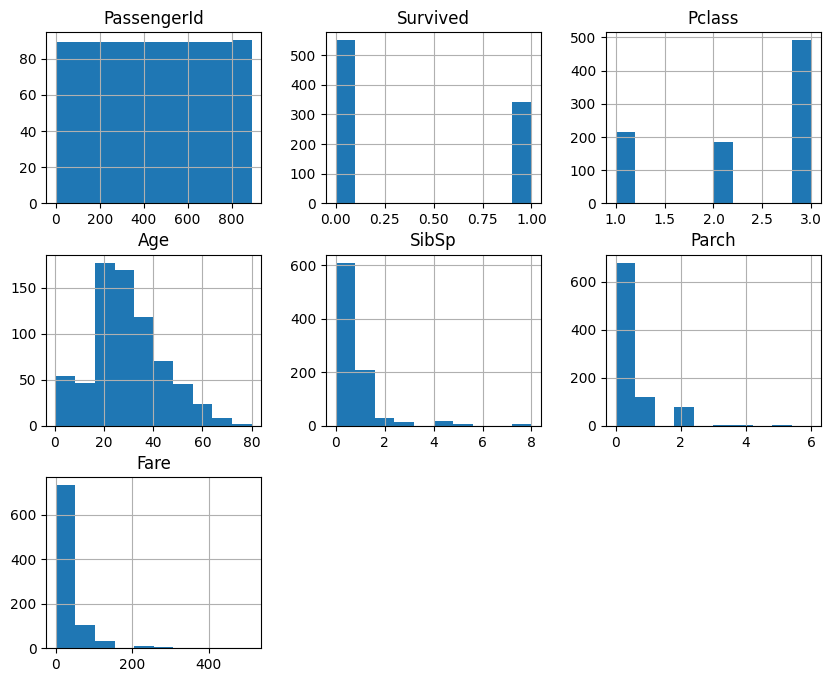

In [393]:
# Generate histogram graph
train.hist(figsize=(10,8))
plt.show()

#### Which groups of people were more likely to survive?

In [394]:
# Analyze the probability of survival by sex
train[['Sex', 'Survived']].groupby(['Sex']).mean()

,Survived
Sex,
female,0.742038
male,0.188908


<Axes: xlabel='Embarked', ylabel='Survived'>

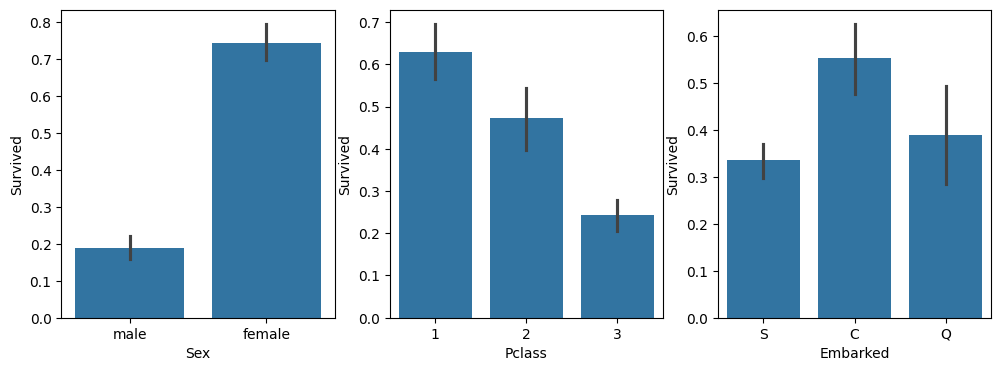

In [395]:
# Plot Survived vs. Sex, Pclass and Embarked Graphs
fig, (axis1, axis2, axis3) = plt.subplots(1,3, figsize=(12,4))

sns.barplot(x='Sex', y='Survived', data=train, ax=axis1)
sns.barplot(x='Pclass', y='Survived', data=train, ax=axis2)
sns.barplot(x='Embarked', y='Survived', data=train, ax=axis3)

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


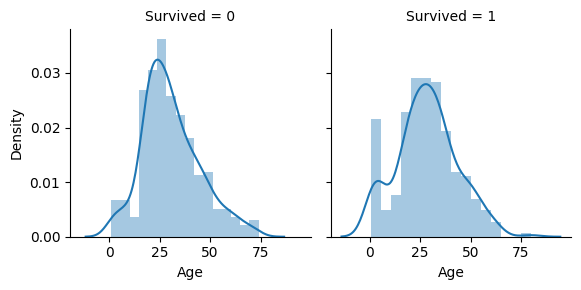

In [396]:
# see influence of age on probability of survival
age_survived = sns.FacetGrid(train, col='Survived')
age_survived.map(sns.distplot, 'Age')

array([[<Axes: xlabel='Parch', ylabel='Parch'>,
        <Axes: xlabel='SibSp', ylabel='Parch'>,
        <Axes: xlabel='Age', ylabel='Parch'>,
        <Axes: xlabel='Pclass', ylabel='Parch'>],
       [<Axes: xlabel='Parch', ylabel='SibSp'>,
        <Axes: xlabel='SibSp', ylabel='SibSp'>,
        <Axes: xlabel='Age', ylabel='SibSp'>,
        <Axes: xlabel='Pclass', ylabel='SibSp'>],
       [<Axes: xlabel='Parch', ylabel='Age'>,
        <Axes: xlabel='SibSp', ylabel='Age'>,
        <Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='Pclass', ylabel='Age'>],
       [<Axes: xlabel='Parch', ylabel='Pclass'>,
        <Axes: xlabel='SibSp', ylabel='Pclass'>,
        <Axes: xlabel='Age', ylabel='Pclass'>,
        <Axes: xlabel='Pclass', ylabel='Pclass'>]], dtype=object)

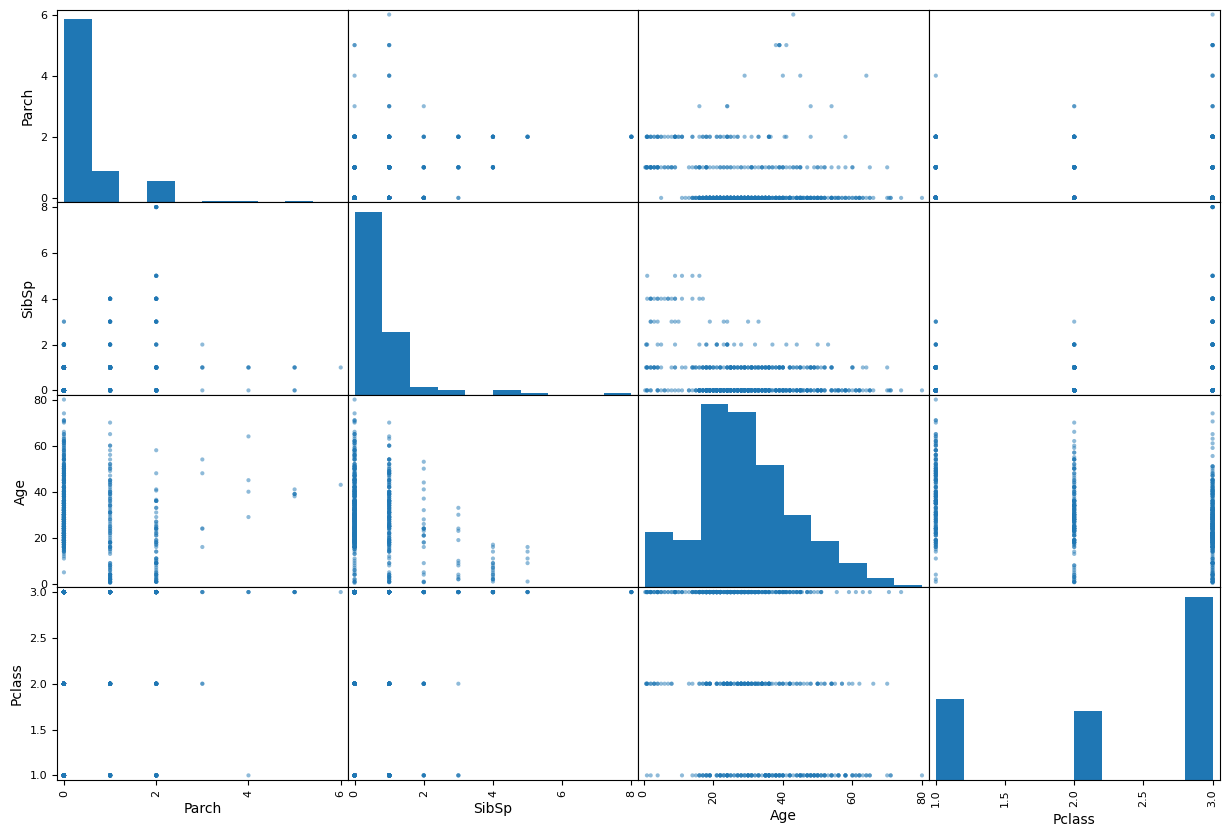

In [397]:
# Plot scatter matrix
columns = ['Parch', 'SibSp', 'Age', 'Pclass']
pd.plotting.scatter_matrix(train[columns], figsize=(15,10))

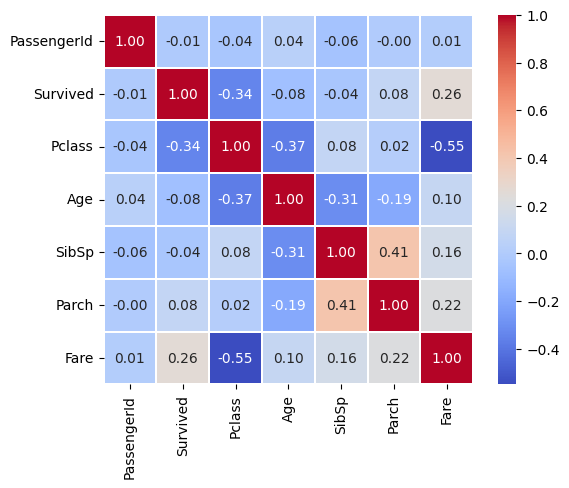

In [398]:
# Plot Heatmap for numerics variables
numeric_cols = train.select_dtypes(include='number')

sns.heatmap(numeric_cols.corr(), cmap='coolwarm', fmt='.2f', linewidths=0.1,
            vmax=1.0, square=True, linecolor='white', annot=True);

The `df.describe()` method can be used to see descriptive statistics for non-numeric columns. To do this, just set the argument `include=['O'].`

In [399]:
train.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


### Looking at these data, we can observe that:

*   Values for `Name` are unique
*   There's not missing values to `Name` and `Sex`
*   There are only the male and female sexes, with the male being the most frequent (577/891 = 65%);
*   The port where the most passengers boarded is S = Southampton.

## Data Preparation

Up to this point, all we have done is import the data into DataFrame structures, formulate hypotheses, begin an exploratory data analysis, and visualize graphs and correlations between the variables we considered relevant.

A data science project is not a fixed, step-by-step process, but rather an iterative one, where we constantly move back and forth whenever necessary.

When we look at someone else's notebook, it always seems well-structured and straight to the point. However, before presenting a clean final version, I usually go back to the beginning countless times!

Remember this: a final version is one that has been rewritten many times. Go back to the start whenever you need to add new insights that make sense.





In [400]:
# Save the dataset indexes for later retrieval
train_index = train.shape[0]
test_index = test.shape[0]

# Save PassegerId to submission to kaggle
passengerId = test['PassengerId']

# Extract 'Survived' Column and delete from train Dataset
target = train.Survived.copy()
train.drop(['Survived'], axis=1, inplace=True)

# Concatenate train and test in the same Dataframe
df_merged = pd.concat(objs=[train, test], axis=0).reset_index(drop=True)

print("df_merged.shape: ({} x {})".format(df_merged.shape[0], df_merged.shape[1]))

df_merged.shape: (1309 x 11)


### Select the Features

Like any real-world dataset, you'll always encounter data that's useless and data that has no weight or significance in your model.

Our judgment can often be flawed, but unfortunately, it's your role, as a data scientist, to choose which features will be used in the Machine Learning model.

In our case, we'll disregard the variables ['PassengerId', 'Name', 'Ticket', 'Cabin'], as they appear to be irrelevant.

In [401]:
df_merged.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

So, we are left with the following variables to be handled and prepared: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'].

### Missing values

Let’s take a look at the missing values in each column and handle those empty fields.

Usually, there are two main approaches when we encounter missing values:

*   Fill these values arbitrarily (with the mean, median, or most frequent value); or
*  Remove the entire row.

Each situation is different, and once again, you — the data scientist — are the one who decides which step to take.

Most of the time, it’s not ideal to discard an entire row just because one field is missing. Whenever possible, it’s better to fill in the missing value — and that’s exactly what we’re going to do.

In [402]:
# Complete or delete missing values in train and test dataset
df_merged.isnull().sum()

,0
Pclass,0
Sex,0
Age,263
SibSp,0
Parch,0
Fare,1
Embarked,2


For the variables Age and Fare, I’ll fill in the missing values with the median.
For the Embarked variable, I’ll use the most frequent value.

In [403]:
# age
age_median = df_merged['Age'].median()
df_merged['Age'] = df_merged['Age'].fillna(age_median)

# fare
fare_median = df_merged['Fare'].median()
df_merged['Fare'] = df_merged['Fare'].fillna(fare_median)

# embarked
embarked_top = df_merged['Embarked'].value_counts().index[0]
df_merged['Embarked'] = df_merged['Embarked'].fillna(embarked_top)

### Prepare variables for modeling

The mathematical model requires us to work with numeric variables, meaning we need to transform the input data from categorical format to numbers.

As you can see below, I converted the possible values ​​of Sex to {'male': 0, 'female': 1}. Regarding the variable Embarked, I applied the concept of dummy variables.

The dummy variables here assume only values ​​0 and 1, creating a new column for each possible value of the categorical variable. To make it easier to understand, here's what the DataFrame looks like after all these changes:

In [404]:
# Convert 'Sex' to 0 or 1
df_merged['Sex'] = df_merged['Sex'].map({'male': 0, 'female': 1})

# Dummie variables for 'Embarked'
embarked_dummies = pd.get_dummies(df_merged['Embarked'], prefix='Embarked')
df_merged = pd.concat([df_merged, embarked_dummies], axis=1)
df_merged.drop('Embarked', axis=1, inplace=True)

display(df_merged.head())

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,False
2,3,1,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,3,0,35.0,0,0,8.0500,False,False,True


### Retrieving the training and testing datasets

Here we've just prepared the dataset for the model, and I'm going to split `df_merged` into `train` and `test`, exactly as it was at the beginning.

Now you can understand the reason for the concatenation above. We'd have double the work and still run the risk of making mistakes at some stage.

In [405]:
# Recover train and test datasets
train = df_merged.iloc[:train_index]
test = df_merged.iloc[train_index:]

### Model Building and Evaluation

The most time-consuming stage of any Data Science project is Exploratory Data Analysis and its preparation/processing.

All the care we took served to understand the problem, test hypotheses, and discard unnecessary/redundant data.

With just a few lines of code, we can create and optimize basic Machine Learning models. Here, we'll build two:

Logistic Regression Model
Decision Tree Model

In [406]:
# Import libraries of ML Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Create Logistic Regression model
lr_model = LogisticRegression(solver='liblinear')
lr_model.fit(train, target)

# Verify Logistic Regression Model accuracy
acc_logReg = round(lr_model.score(train, target) * 100, 2)
print("Accuracy of the Logistic Regression Model: {}".format(acc_logReg))

Accuracy of the Logistic Regression Model: 80.13


With just two lines, we built a Logistic Regression model with 80% accuracy based on the training dataset.

This result is excellent for a first model. I'll take this opportunity to make predictions on the test dataset so we can submit it to Kaggle and compare performance.

In [407]:
y_pred_lr = lr_model.predict(test)

submission = pd.DataFrame({
    "PassengerId": passengerId,
    "Survived": y_pred_lr
})

# Generate csv file
submission.to_csv('./submission_lr.csv', index=False)

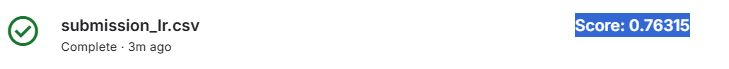

It's not uncommon to experience poor performance when submitting predictions, as our model was trained 100% on the training set: this means it has a much better fit with the training dataset.

Let's see how a model based on Decision Trees performs, following the same steps.

In [408]:
# Create a decision tree model
tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(train, target)

# Check the accuracy of the model
acc_tree = round(tree_model.score(train, target) * 100, 2)
print("Acurácia do modelo de Árvore de Decisão: {}".format(acc_tree))

Acurácia do modelo de Árvore de Decisão: 82.72


In [409]:
y_pred_tree = tree_model.predict(test)

submission = pd.DataFrame({
    "PassengerId": passengerId,
    "Survived": y_pred_tree
})

# gerar arquivo csv
submission.to_csv('./submission_tree.csv', index=False)

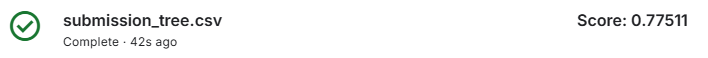

Finally, since our model is ready, let’s see whether my girlfriend Julia and I would have survived the Titanic disaster.

Let’s assume we were traveling in 2nd class, I’m 35 years old, she’s 30, with our baby X, having paid the average ticket price, and embarked from Southampton (UK).

In [410]:
# declare the variable values for me and my girlfriend
augusto = np.array([2, 0, 35, 1, 32.2, 0, 0, 0, 1]).reshape((1, -1))
julia = np.array([2, 1, 30, 1, 32.2, 0, 0, 0, 1]).reshape((1, -1))

# check if we would have survived
print("Augusto:\t{}".format(tree_model.predict(augusto)[0]))
print("Julia:\t\t{}".format(tree_model.predict(julia)[0]))

Augusto:	0
Julia:		1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Unfortunately, according to my own model, I wouldn’t have survived the Titanic disaster.

However, Julia was predicted to survive.
It seems that, just like in James Cameron’s movie, the outcome also favored women.